In [1]:
import os

In [2]:
from koopman_gravity import data_loading_pipeline as dlp

In [ ]:
FIG_DIR = "figures/trajectory_mapping_game_xy_based_umap_110926"
os.makedirs(FIG_DIR, exist_ok=True)

In [4]:
GAME_DATA_PATH = "umap_projections/xy_vase_umap_projection_full.parquet"

In [5]:
trajectory_df, trajectory_edges, trajectory_pairs, Z, Z_prime = dlp(GAME_DATA_PATH, source = "game")

In [6]:
from koopman_gravity import get_umap_bounds

In [7]:
COMBINED_DATA_PATH = "umap_projections/combined_vase_umap_projection.parquet"

In [8]:
umap_bounds = get_umap_bounds(COMBINED_DATA_PATH)

In [9]:
from koopman_gravity import gravity_pipeline

In [10]:
phi_2D, U, V, centres, sigma = gravity_pipeline(trajectory_df, trajectory_edges, umap_bounds)

Building Koopman Gram matrices: 100%|██████████| 3/3 [00:00<00:00,  6.85it/s]


Orientation check — Pearson(+): 0.0160  |  Pearson(−): -0.0160
Keeping original orientation.


In [11]:
from koopman_gravity import compute_selection_entropy

In [12]:
entropy_grid, count_grid, x_edges, y_edges = compute_selection_entropy(trajectory_pairs, trajectory_df, umap_bounds)

Cells with ≥5 selected transitions: 358 / 900
Entropy range: 0.241 – 0.985


In [13]:
from koopman_gravity import plot_gravity_field, plot_selection_entropy, plot_entropy_vs_gravity

In [14]:
N_GRID = 30
grid_x = centres[:, 0].reshape(N_GRID, N_GRID)
grid_y = centres[:, 1].reshape(N_GRID, N_GRID)

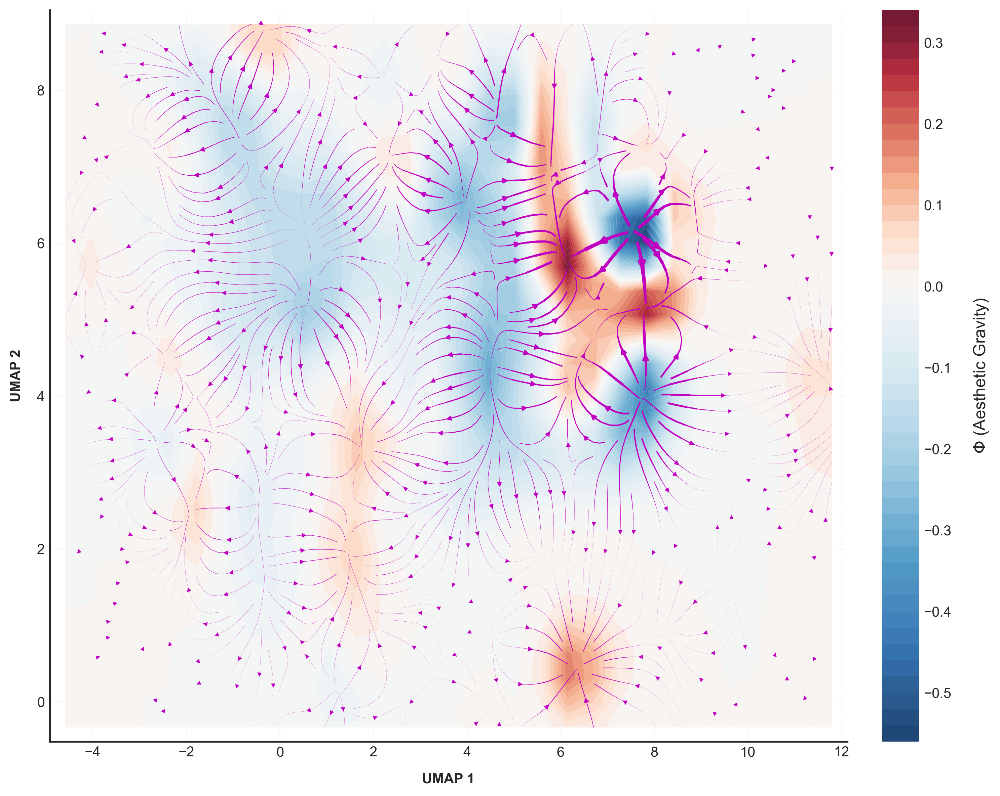

In [15]:
plot_gravity_field(
    grid_x, grid_y, phi_2D, U, V,
    umap_bounds["xlim"], umap_bounds["ylim"],
    title=None,
    save_path=os.path.join(FIG_DIR, "gravity_field.png"),
)

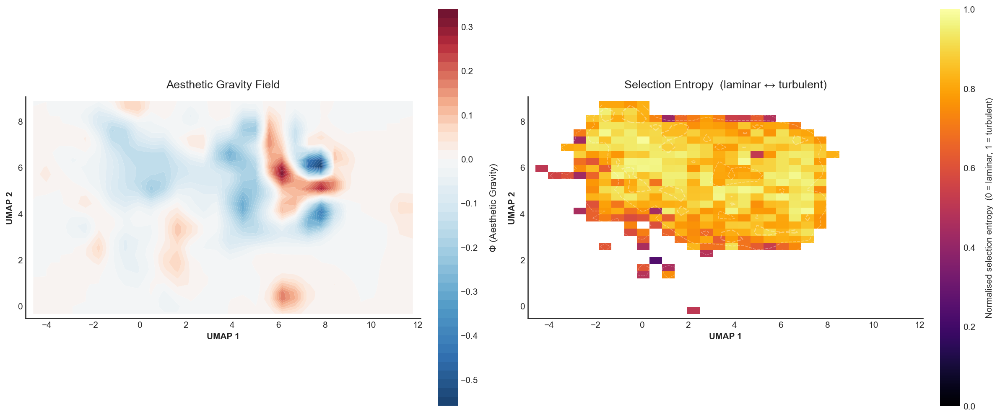

In [16]:
plot_selection_entropy(
    grid_x, grid_y, phi_2D,
    entropy_grid, count_grid, x_edges, y_edges,
    umap_bounds["xlim"], umap_bounds["ylim"],
    save_path=os.path.join(FIG_DIR, "gravity_vs_entropy.png"),
)

Non-normal distribution detected (Shapiro-Wilk p < 0.05) — Spearman preferred.
Gravity φ vs selection entropy  (n=358 cells)
  Pearson  r = -0.1675  |  Spearman ρ = -0.2302


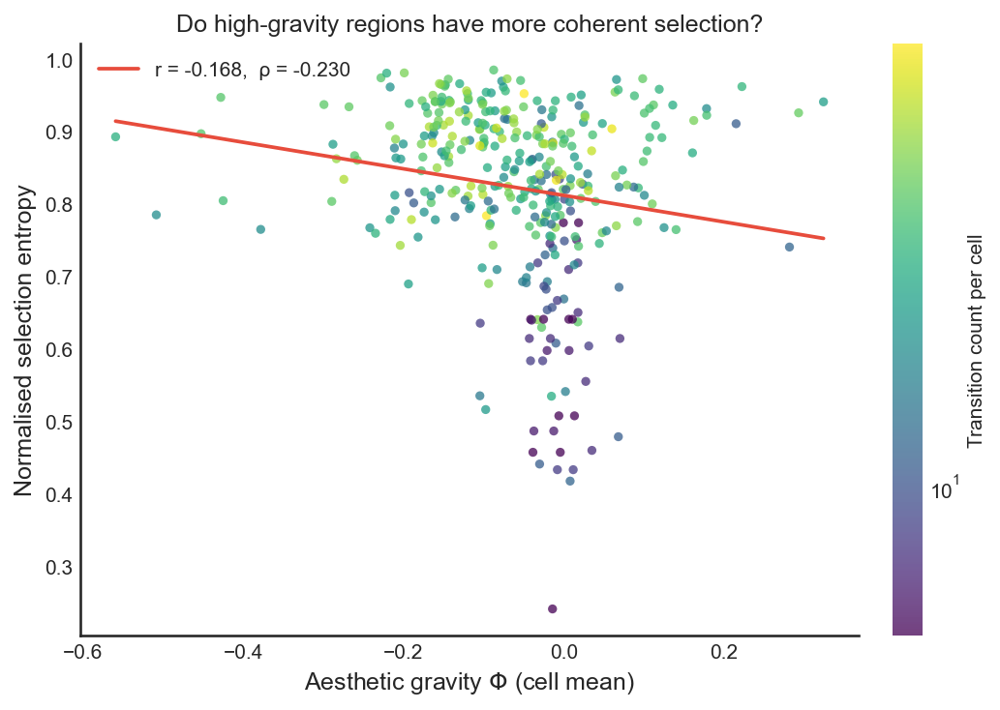

In [17]:
plot_entropy_vs_gravity(
    phi_2D, entropy_grid, count_grid,
    save_path=os.path.join(FIG_DIR, "entropy_vs_gravity_scatter.png"),
)

In [18]:
from scipy.interpolate import RegularGridInterpolator
from koopman_gravity import plot_vase_grid
import numpy as np

# Interpolate phi_2D onto each vase's UMAP position to get a per-vase gravity score.
# gravity_pipeline doesn't expose the eigenvector, so we evaluate the precomputed grid instead.
x_coords = np.linspace(umap_bounds["x_min"], umap_bounds["x_max"], N_GRID)
y_coords = np.linspace(umap_bounds["y_min"], umap_bounds["y_max"], N_GRID)
phi_interp = RegularGridInterpolator(
    (y_coords, x_coords), phi_2D, method="linear", bounds_error=False, fill_value=None
)

vase_meta = (
    trajectory_df[["vase_id", "umap_x", "umap_y"]]
    .drop_duplicates("vase_id")
    .reset_index(drop=True)
    .copy()
)
vase_meta["aesthetic_gravity"] = phi_interp(vase_meta[["umap_y", "umap_x"]].to_numpy())
print(f"vase_meta: {len(vase_meta):,} unique vases")

vase_meta: 81,720 unique vases


In [19]:
import pandas as pd

# Load XY contour points and reconstruct the vase_id key (participant_id::generation_key::vase)
# to match trajectory_df. Only load the 5 columns needed; filter to game vases only.
xy_raw = pd.read_parquet(
    "../file_processing/processed/xy_data.parquet",
    columns=["participant_id", "generation_key", "vase", "x", "y"],
)
xy_raw["vase_id"] = xy_raw["participant_id"] + "::" + xy_raw["generation_key"] + "::" + xy_raw["vase"]

valid_ids = set(vase_meta["vase_id"])
game_xy_df = (
    xy_raw[xy_raw["vase_id"].isin(valid_ids)][["vase_id", "x", "y"]]
    .reset_index(drop=True)
)
del xy_raw
print(f"game_xy_df: {game_xy_df['vase_id'].nunique():,} vase contours, {len(game_xy_df):,} rows")

game_xy_df: 81,720 vase contours, 20,430,000 rows


In [20]:
plot_vase_grid(
    game_xy_df, vase_meta, umap_bounds,
    n_grid=100,
    save_path=os.path.join(FIG_DIR, "vase_gravity_grid.png"),
)

In [21]:
from koopman_gravity import plot_vase_silhouette

# Score all real museum vases against the current gravity field via interpolation
real_umap = (
    pd.read_parquet(
        "umap_projections/real_vase_umap_projection.parquet",
        columns=["vase_id", "umap_x", "umap_y"],
    )
    .drop_duplicates("vase_id")
    .reset_index(drop=True)
)
real_umap["aesthetic_gravity"] = phi_interp(real_umap[["umap_y", "umap_x"]].to_numpy())

best_row = real_umap.loc[real_umap["aesthetic_gravity"].idxmax()]
print(f"Most beautiful: {best_row['vase_id']}  (φ = {best_row['aesthetic_gravity']:.4f})")
print(f"UMAP position:  ({best_row['umap_x']:.3f}, {best_row['umap_y']:.3f})")
print(f"Gravity range:  {real_umap['aesthetic_gravity'].min():.4f} – {real_umap['aesthetic_gravity'].max():.4f}")

Most beautiful: met_326765  (φ = 0.2014)
UMAP position:  (6.143, 6.260)
Gravity range:  -0.5066 – 0.2014


Contour points loaded: 250


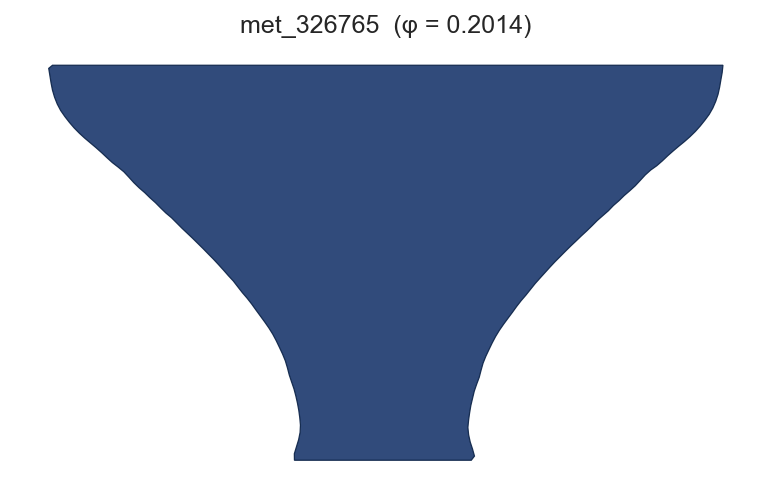

In [22]:
# Load only the winning vase's contour via predicate pushdown (avoids reading all 26M rows)
best_contour = (
    pd.read_parquet(
        "../real_vase_data/all_profiles_120526.parquet",
        filters=[("gpp_no", "==", best_row["vase_id"])],
    )
    .sort_values("point_order")
    .rename(columns={"gpp_no": "vase_id"})
)
print(f"Contour points loaded: {len(best_contour)}")

plot_vase_silhouette(
    best_contour,
    title=f"{best_row['vase_id']}  (φ = {best_row['aesthetic_gravity']:.4f})",
    save_path=os.path.join(FIG_DIR, f"most_beautiful_{best_row['vase_id']}.png"),
)